# Designing Effective Reward Functions in Reinforcement Learning

A reinforcement-learning agent optimizes the reward signal it receives. A powerful learning algorithm cannot compensate for a reward function that encourages the wrong behavior.

This notebook studies reward design through four examples:

1. **GridWorld** — why apparently reasonable rewards can make learning slow or produce undesirable behavior.
2. **CartPole** — how shaped rewards can provide dense feedback about stability.
3. **Mountain Car** — how reward shaping can speed learning but also create unintended incentives.
4. **Lunar Lander** — how several objectives can be combined into one shaped reward.

The central lesson is

$$
\boxed{\text{The agent learns what the reward function asks for, not what we intended.}}
$$

### How to read this notebook

The central idea is simple: the learning algorithm does not directly know what behavior we want. It only sees states, actions, and numerical rewards. Therefore, the reward function becomes the agent's operational definition of "good" and "bad" behavior.

A reward can fail in two different ways:

- it can be **too weak or too sparse**, so the agent receives very little guidance about which actions are useful;
- it can be **misaligned with the real objective**, so the agent learns efficiently but learns the wrong behavior.

The examples below are useful because they move from a very simple navigation problem to systems with continuous state variables and several competing objectives.


## 1. Why Reward Design Matters

The reward function is the learning signal that tells the agent which outcomes are desirable.

For a transition

$$
S_t \xrightarrow{A_t} (R_{t+1},S_{t+1}),
$$

the reward $R_{t+1}$ contributes to the return

$$
G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots.
$$

The agent changes its behavior to maximize expected return. If the reward signal does not represent the real objective correctly, the learned policy can also be wrong even when the learning algorithm is working correctly.

### Reward, return, and behavior

The immediate reward $R_{t+1}$ tells the agent what happened after one transition, while the return $G_t$ measures the accumulated future consequence of the current decision. This distinction matters because reinforcement learning does not normally optimize one isolated reward; it tries to maximize expected cumulative return.

For example, if $\gamma=0.9$ and the next three rewards are

$$
R_{t+1}=1,\qquad R_{t+2}=2,\qquad R_{t+3}=3,
$$

then the return from time $t$ is

$$
G_t=1+0.9(2)+0.9^2(3)=5.23.
$$

So a reward function affects the entire learning problem. If an undesirable behavior repeatedly produces a larger cumulative return than the desired behavior, the agent has a mathematical reason to prefer the undesirable behavior.

A useful way to think about reward design is therefore

$$
\boxed{\text{Desired behavior} \longrightarrow \text{reward definition} \longrightarrow \text{return} \longrightarrow \text{learned policy}}.
$$

The learning algorithm can optimize the signal it is given, but it cannot infer an objective that is missing from that signal.


# 2. GridWorld: Three Reward Designs

Consider a GridWorld in which the agent starts somewhere in the grid and must reach a goal. Small changes to the reward definition can completely change what the agent is encouraged to do.

The GridWorld example isolates reward design from other complications. The state can be thought of as the agent's current grid location, the actions move the agent through the grid, and the goal is a terminal state. Because the environment is simple, it is easy to see how a small change in reward changes the behavior that maximizes return.


## 2.1 Zero Reward Until the Goal

The first design is

$$
R=\begin{cases}
+1, & \text{goal reached},\\
0, & \text{otherwise}.
\end{cases}
$$

This is simple, but during most of the episode the agent receives $0$. A step toward the goal and a step away from the goal initially look identical from the reward signal alone.

The agent can still learn with enough exploration, but learning becomes slow as the state space grows.

### Why this reward is difficult to learn from

Suppose two nonterminal actions are available:

- Action A moves the agent one cell closer to the goal.
- Action B moves the agent one cell farther from the goal.

Under this reward definition, both actions immediately produce

$$
R=0.
$$

Before the agent has actually reached the goal enough times for the successful return to propagate backward through learning, the reward signal does not distinguish A from B.

The reward is therefore **correct at the terminal state**, but it is not very informative during the path. The agent may need substantial random exploration before it experiences the $+1$ event that tells it which earlier state-action choices were useful.

As the grid becomes larger, a randomly exploring agent has many more possible trajectories. The source uses this example to show why a reward can be logically correct and still make learning unnecessarily slow.


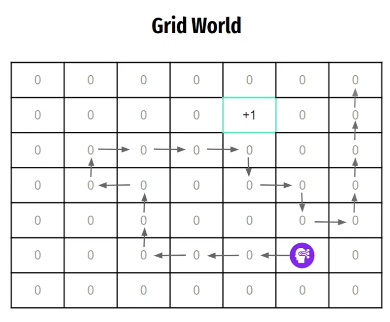

This is a **sparse-reward** problem. Before the goal is discovered, the trajectory may look like

$$
0,0,0,0,\ldots
$$

so the agent receives very little information about whether its current behavior is improving.

Sparse does not mean that the reward is mathematically invalid. It means that informative feedback is rare.

If an episode contains 20 transitions and only the final transition produces a nonzero reward, then 19 of the 20 immediate rewards provide no direct distinction between progress and deterioration. The learning algorithm must connect the delayed terminal outcome to earlier decisions through return estimation and repeated experience.

This is especially difficult when successful episodes are rare.


## 2.2 Positive Reward for Every Step

Now suppose

$$
R=\begin{cases}
+10, & \text{goal reached},\\
+1, & \text{every ordinary step}.
\end{cases}
$$

This gives dense feedback, but it creates the wrong incentive: the agent is rewarded for continuing to move.

A long path can accumulate many positive rewards before reaching the goal. The reward does not clearly express the objective **reach the goal in the fewest steps**.

So dense reward is not automatically good reward.

### Why the extra positive feedback is misleading

At first, $+1$ per step looks more informative than $0$ per step. The problem is that the sign of the reward now favors remaining active.

For $\gamma=1$, suppose one successful path reaches the goal after 4 ordinary steps and another reaches it after 9 ordinary steps. Their returns are

$$
G_{\text{short}}=4(1)+10=14,
$$

$$
G_{\text{long}}=9(1)+10=19.
$$

The longer path has the larger return. Therefore, if episode termination is not otherwise handled in a way that prevents exploitation, the reward function can prefer delay even though the real objective is fast completion.

This is the key lesson: **more frequent reward does not guarantee better guidance**. A dense reward is useful only when its incentives agree with the task objective.

### A second problem: repeated rewarded paths

The source also points out another problem with giving \(+1\) for every ordinary step. If the agent revisits a state and previously received a positive reward after taking a particular action there, that action may already have a higher learned value. Without a separate exploration mechanism, the agent can therefore keep selecting the same rewarded action and repeat the same path.

So this design can fail in two ways:

$$
\boxed{
\mathrm{Positive\ reward\ for\ moving}
\;\Rightarrow\;
\mathrm{Repeated\ rewarded\ motion}
}
$$

and

$$
\boxed{
\mathrm{More\ steps}
\;\Rightarrow\;
\mathrm{More\ accumulated\ positive\ reward}
}
$$

The reward encourages activity, but it does not say that the goal should be reached as early as possible.


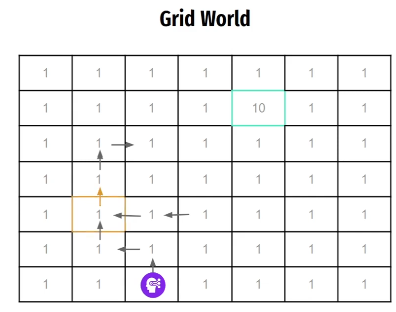

## 2.3 Negative Step Reward

A classic alternative is

$$
R=\begin{cases}
0 \text{ or } +1, & \text{goal reached},\\
-1, & \text{every ordinary step}.
\end{cases}
$$

Every extra step now has a cost. If the agent takes $N$ ordinary steps before a terminal reward $R_G$, then for $\gamma=1$,

$$
G=-N+R_G.
$$

Maximizing return therefore encourages fewer steps and faster completion.

### Why the negative step cost changes the objective

Now compare two successful paths when the terminal reward is $+1$ and $\gamma=1$:

$$
G_{\text{short}}=-4+1=-3,
$$

$$
G_{\text{long}}=-9+1=-8.
$$

Because $-3>-8$, the shorter path is preferred.

Every unnecessary transition reduces return, so reaching the terminal state earlier becomes valuable. The source describes this as continuously penalizing the agent until it reaches the goal.

The important point is not that negative rewards are always better. The point is that the sign and magnitude of each reward term should encode the behavior we actually want.

### Why the source says this can encourage exploration

The source gives an intuitive explanation based on revisiting a state. Suppose the agent previously took an action from a state and received \(-1\). When it returns to that state, that action is now associated with a negative outcome, so trying a different action can become preferable.

This does not replace an explicit exploration policy such as \(\epsilon\)-greedy exploration, but it explains why a step penalty can discourage repeatedly following an unproductive path. The same penalty also makes every unnecessary transition reduce the return.


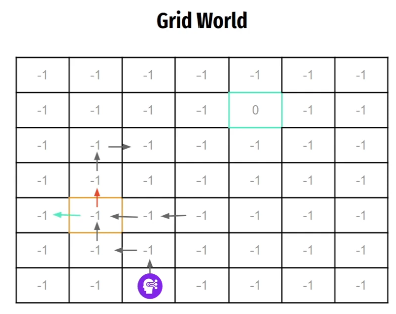

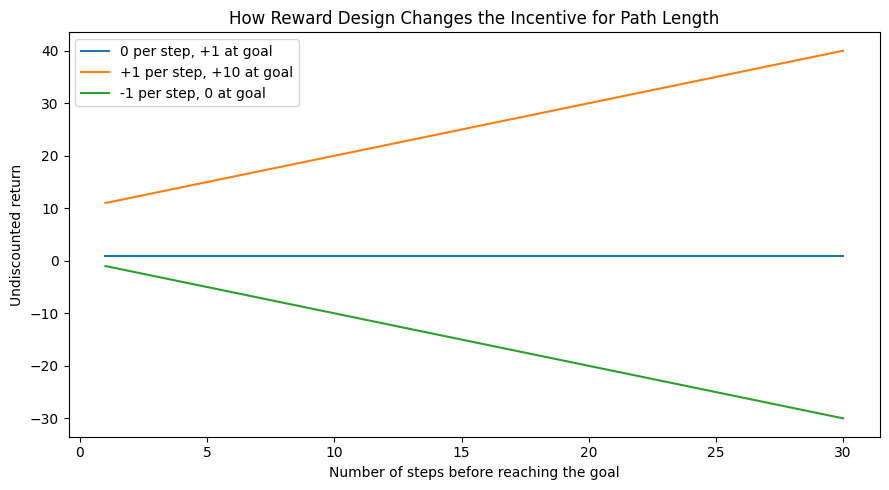

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

steps = np.arange(1, 31)
sparse_return = np.ones_like(steps, dtype=float)
positive_step_return = steps + 10
step_penalty_return = -steps

plt.figure(figsize=(9, 5))
plt.plot(steps, sparse_return, label="0 per step, +1 at goal")
plt.plot(steps, positive_step_return, label="+1 per step, +10 at goal")
plt.plot(steps, step_penalty_return, label="-1 per step, 0 at goal")
plt.xlabel("Number of steps before reaching the goal")
plt.ylabel("Undiscounted return")
plt.title("How Reward Design Changes the Incentive for Path Length")
plt.legend()
plt.tight_layout()
plt.show()

The incentive structure is now clear:

- **Sparse goal reward:** successful paths can receive similar return even if one is much longer.
- **Positive step reward:** longer paths can become more rewarding.
- **Step penalty:** shorter paths produce higher return.

The step penalty still does not directly tell the agent how close it is to the goal.

This comparison separates two questions that are easy to confuse:

1. **Does the reward eventually identify success?**
2. **Does the reward provide useful guidance before success?**

A terminal reward can answer the first question while doing little for the second. A negative step cost adds pressure to finish quickly, but it still does not explicitly encode distance to the goal. That limitation motivates shaped rewards.


# 3. Sparse Rewards vs. Shaped Rewards

## 3.1 Sparse Rewards

A sparse reward provides useful feedback only occasionally. A conceptual example

$$
R(d)=\begin{cases}
+1, & d<0.1,\\
0, & d\ge 0.1,
\end{cases}
$$

where $d$ is distance from the goal.

If the agent moves from $d=0.3$ to $d=0.8$, both positions still produce zero reward, so the reward does not reveal that the agent moved farther away.

### Why distance matters in this example

For the threshold reward above, consider

$$
d_1=0.30,\qquad d_2=0.80.
$$

Both satisfy $d\ge 0.1$, so

$$
R(d_1)=R(d_2)=0.
$$

Yet $d_2$ is much farther from the goal. The reward compresses many qualitatively different states into the same numerical signal.

That is the central difficulty of sparse reward: the environment may contain useful information about progress, but the reward function does not expose that information to the learning process.


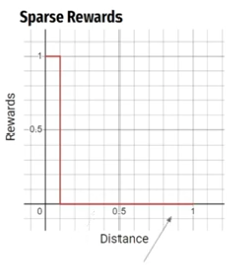

## 3.2 Shaped Rewards

A shaped reward gives more informative feedback during the trajectory. Instead of changing only at the goal, the reward changes as the agent becomes better or worse according to useful task variables.

The intended pattern is

$$
\boxed{\text{closer to desirable behavior} \Rightarrow \text{better reward}}
$$

and

$$
\boxed{\text{moving away from desirable behavior} \Rightarrow \text{worse reward}}.
$$

This can make learning faster because every transition carries information.

### What shaping adds

A shaped reward introduces an intermediate measure of quality. If $d_t$ is distance to the goal, for example, a shaping score might assign better values to smaller distances. Then two nearby transitions can produce different feedback even when neither transition reaches the terminal state.

Conceptually,

$$
d_{t+1}<d_t
\quad\Rightarrow\quad
\text{progress toward the goal},
$$

while

$$
d_{t+1}>d_t
\quad\Rightarrow\quad
\text{movement away from the goal}.
$$

This gives the agent information at many more steps.

The trade-off is that the designer now has more influence over what the agent learns. A poorly chosen shaping variable can make training faster while steering the policy toward an unintended strategy.


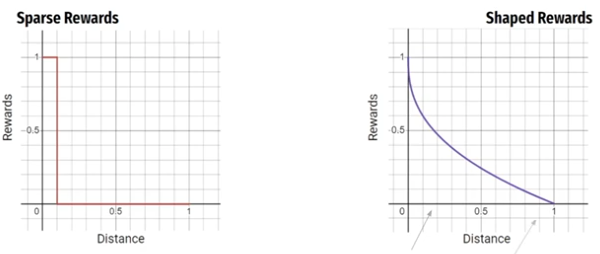

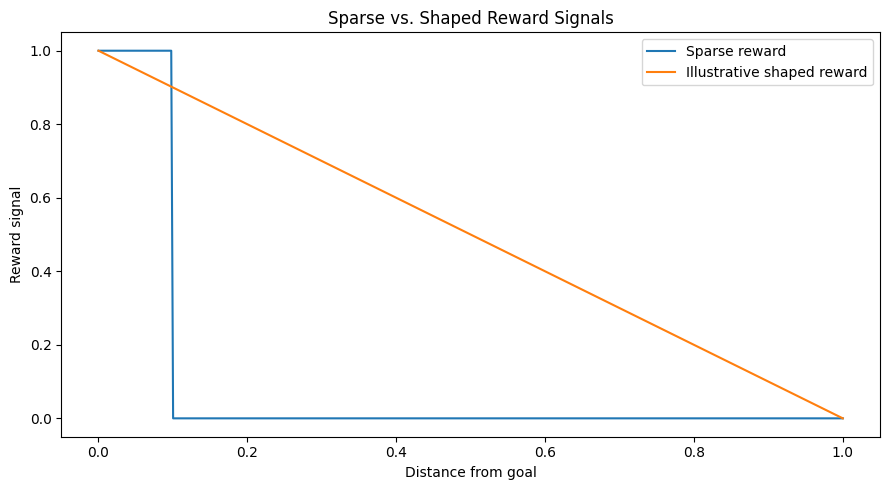

In [2]:
distance = np.linspace(0, 1, 400)
sparse = np.where(distance < 0.1, 1.0, 0.0)
shaped = 1.0 - distance

plt.figure(figsize=(9, 5))
plt.plot(distance, sparse, label="Sparse reward")
plt.plot(distance, shaped, label="Illustrative shaped reward")
plt.xlabel("Distance from goal")
plt.ylabel("Reward signal")
plt.title("Sparse vs. Shaped Reward Signals")
plt.legend()
plt.tight_layout()
plt.show()

The smooth curve above is only an illustration of the shaped-reward idea.

### Trade-off

Shaped rewards can make learning easier and faster, but they are harder to design. A poorly designed shaped reward can produce behavior that maximizes the shaping signal while violating the real objective.

The important comparison is therefore not simply

$$
\text{sparse reward} \quad \text{vs.} \quad \text{dense reward}.
$$

The more useful comparison is

$$
\boxed{\text{Does the reward make desirable behavior produce higher return?}}
$$

A sparse reward can be slow but aligned. A shaped reward can be fast but misaligned. Reward design must consider both learning speed and the final behavior.


# 4. Shaped Rewards for CartPole

The CartPole task requires the agent to move the cart left or right while keeping the pole upright.

A useful reward should indicate whether the system is moving **toward** or **away from** a stable configuration.

In CartPole, the desired state is not represented by one variable alone. The pole should remain near upright, the cart should remain in a useful region, and large velocities can indicate that the system is moving toward instability.

This makes CartPole a good example of a **multi-component shaped reward**: several state variables can be combined into one score describing how desirable the current state is.


## 4.1 Difference-Based Shaping

Let $\Phi(S)$ be a shaping score. The difference between current and previous shaping values:

$$
\boxed{R_t=\Phi(S_t)-\Phi(S_{t-1})}.
$$

If the new state is more stable, the shaping score improves and the reward becomes positive. If the state becomes worse, the reward becomes negative.

### Interpreting the subtraction

The shaping score $\Phi(S)$ is not itself the transition reward in this construction. Instead, the reward measures **change in shaping quality**.

If

$$
\Phi(S_{t-1})=-9
$$

and the new state is better,

$$
\Phi(S_t)=-4,
$$

then

$$
R_t=(-4)-(-9)=+5.
$$

The positive reward says that the system improved.

If the new state is worse,

$$
\Phi(S_t)=-12,
$$

then

$$
R_t=(-12)-(-9)=-3.
$$

The negative reward says that the system moved away from the desired condition.

This is why both the previous and current state are needed: the reward describes the direction of change, not only the absolute condition.


## 4.2 Why Raw Pole Angle Is Not Enough

Pole angle can be positive on one side and negative on the other. Using the raw signed angle can therefore give inconsistent signals.

For a symmetric objective such as staying upright, use a direction-independent measure such as

$$
|\theta|
$$

or

$$
\theta^2
$$

Here we develop the squared form.

### Why the sign of the angle causes trouble

Suppose the pole is $4^\circ$ from upright. Depending on direction, the raw angle may be

$$
\theta = +4^\circ
$$

or

$$
\theta = -4^\circ
$$

Both represent the same size of error, so they should be treated similarly when the objective is simply to stay upright. Using the signed angle directly can make one side appear numerically better than the other.

Squaring removes the direction:

$$
(+4)^2 = (-4)^2 = 16
$$

The absolute value does the same:

$$
|+4| = |-4| = 4
$$

This is a general reward-design rule: when positive and negative deviations are equally undesirable, the error measure should usually depend on the **magnitude** of the deviation rather than its sign.

### The exact sign problem shown in the source

The source first considers using the pole angle directly in the shaping difference.

Suppose the pole moves from the balanced position to $+4^\circ$. If the shaping value were simply the raw angle,

$$
\Phi_{t-1} = 0, \qquad \Phi_t = 4
$$

then

$$
R_t = \Phi_t - \Phi_{t-1} = 4 - 0 = +4
$$

That is the wrong sign because the pole moved away from balance.

A first fix is to store the negative angle:

$$
\Phi_t = -\theta_t
$$

Then the same transition gives

$$
\Phi_{t-1} = 0, \qquad \Phi_t = -4
$$

so

$$
R_t = -4 - 0 = -4
$$

which correctly penalizes the movement away from balance.

However, this still fails on the other side. If the pole is at $-4^\circ$ and recovers to $0^\circ$,

$$
\Phi_{t-1} = -(-4) = +4, \qquad \Phi_t = 0
$$

and therefore

$$
R_t = 0 - 4 = -4
$$

The pole improved, but the reward is negative. This is why the sign of the angle must be removed.

Using the negative squared angle,

$$
\Phi_t = -\theta_t^2
$$

gives

$$
\Phi_{t-1} = -(-4)^2 = -16, \qquad \Phi_t = 0
$$

and

$$
\boxed{R_t = 0 - (-16) = +16}
$$

Now the reward is positive because the pole moved from an error of $4^\circ$ back to the upright position.
which correctly rewards recovery toward the upright position.


## 4.3 Include Multiple State Variables

The video includes:

- $pa$: pole angle,
- $cp$: cart position,
- $cv$: cart velocity,
- $pav$: pole angular velocity.

The shaping score is

$$
\boxed{\Phi_t=-\left(pa_t^2+cp_t^2+cv_t^2+pav_t^2\right)}
$$

and

$$
\boxed{R_t=\Phi_t-\Phi_{t-1}}.
$$

The best shaping value is near zero. Large deviations make the score more negative.

### Meaning of each term

Each squared term measures a different kind of deviation:

- $pa_t^2$ penalizes the pole for leaning away from upright.
- $cp_t^2$ penalizes the cart for moving away from the center region.
- $cv_t^2$ penalizes large cart motion.
- $pav_t^2$ penalizes rapid pole rotation.

The leading minus sign makes the shaping score largest when these quantities are near zero:

$$
pa_t\approx 0,\quad cp_t\approx 0,\quad cv_t\approx 0,\quad pav_t\approx 0
\quad\Rightarrow\quad
\Phi_t\approx 0.
$$

As instability grows, the sum of squared deviations increases and $\Phi_t$ becomes more negative.

The source also describes combining these state deviations with a square-root/RMS-style scaling in the implementation. The main idea remains the same: the shaping score should worsen as the system moves farther from the balanced state.

### Square-root form shown in the source slide

After adding pole angle, cart position, cart velocity, and pole angular velocity, the source slide shows the combined shaping quantity with a square root:

$$
\boxed{
\Phi_t =
-\sqrt{
pa_t^2 + cp_t^2 + cv_t^2 + pav_t^2
}
}
$$

The narration describes this as an RMS-style combination. Strictly, the displayed expression is a negative root-sum-of-squares because it does not divide the squared sum by the number of components before taking the square root.

The interpretation is unchanged: the best value is close to \(0\), and larger deviations in any of the four state variables make the shaping score more negative. The transition reward is still obtained from the change in shaping:

$$
\boxed{R_t = \Phi_t - \Phi_{t-1}}
$$

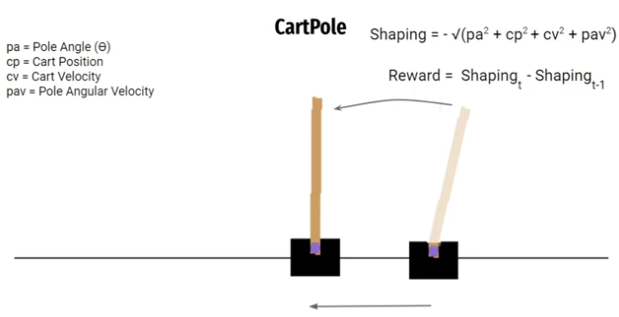

In [3]:
def cartpole_shaping(pole_angle, cart_position, cart_velocity, pole_angular_velocity):
    return -(pole_angle**2 + cart_position**2 + cart_velocity**2 + pole_angular_velocity**2)

def cartpole_shaped_reward(previous_state, current_state):
    return cartpole_shaping(*current_state) - cartpole_shaping(*previous_state)

examples = [
    ("Moving away from balance", (0.05,0.05,0.05,0.05), (0.20,0.10,0.10,0.15)),
    ("Recovering toward balance", (0.20,0.10,0.10,0.15), (0.05,0.05,0.05,0.05)),
]

rows = []
for name, previous_state, current_state in examples:
    rows.append({
        "Transition": name,
        "Previous shaping": cartpole_shaping(*previous_state),
        "Current shaping": cartpole_shaping(*current_state),
        "Reward": cartpole_shaped_reward(previous_state, current_state),
    })

pd.DataFrame(rows)

,Transition,Previous shaping,Current shaping,Reward
0,Moving away from balance,-0.0100,-0.0825,-0.0725
1,Recovering toward balance,-0.0825,-0.0100,0.0725


The reward sign now has the desired interpretation:

- moving away from balance produces a negative reward,
- recovering toward balance produces a positive reward.

The reports that this shaped reward allowed the agent to learn balance in roughly **70 episodes**, compared with about **200 episodes** in the earlier run.

A useful interpretation is

$$
\boxed{
\text{current state closer to balance than previous state}
\Rightarrow R_t>0
}
$$

and

$$
\boxed{
\text{current state farther from balance than previous state}
\Rightarrow R_t<0.
}
$$

This gives the agent feedback even before the pole actually falls. It can therefore learn corrective actions from small changes in stability rather than waiting only for episode termination.


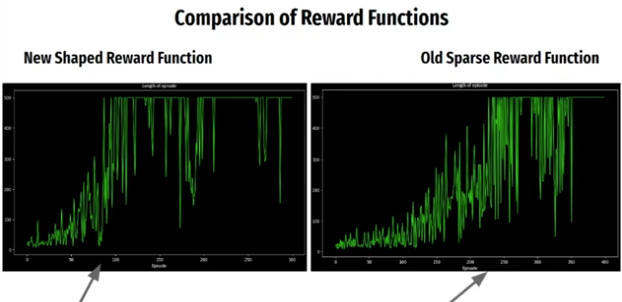

# 5. Shaped Rewards for Mountain Car

The baseline reward in the video is

$$
R=\begin{cases}
0, & \text{goal reached},\\
-1, & \text{otherwise}.
\end{cases}
$$

This encourages fewer steps but does not directly say whether the car is getting closer to the goal.

The baseline Mountain Car reward answers one question well: **Did the agent finish quickly?** Since every nonterminal step costs $-1$, a shorter successful episode has a higher return.

However, early in training the agent may spend many steps in the valley without reaching the goal. During those steps, the reward remains the same regardless of whether the car is moving into a more promising position. This is why the example next adds information about position and velocity.


## 5.1 Position-Based Shaping

Let $p_t$ be the car position. The first shaped reward uses

$$
\boxed{\Phi_t=p_t+0.5}
$$

and

$$
\boxed{R_t=\Phi_t-\Phi_{t-1}}.
$$

Moving in the direction that increases the shaping score gives positive reward; moving the other way gives negative reward.

### Interpreting the position difference

Because the reward is based on the change in $\Phi$,

$$
R_t=(p_t+0.5)-(p_{t-1}+0.5)=p_t-p_{t-1}.
$$

So the constant $0.5$ cancels in the difference itself. Its role is mainly to rescale the shaping quantity used in the example.

If the position increases from

$$
p_{t-1}=-0.60
$$

to

$$
p_t=-0.55,
$$

then

$$
R_t=-0.55-(-0.60)=+0.05.
$$

If the car instead moves from $-0.60$ to $-0.65$,

$$
R_t=-0.65-(-0.60)=-0.05.
$$

The sign therefore tells the agent whether this local transition moved in the direction associated with the goal.


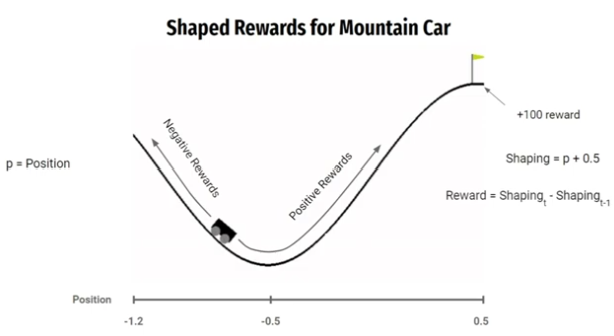

## 5.2 Encourage Velocity

Mountain Car must build momentum by oscillating. therefore incorporates the magnitude of velocity so that, for a comparable position, higher speed receives a stronger signal.

The use of $|v|$ matters because velocity changes sign when the car changes direction.

It also scales the small reward values by a large constant in this experiment and gives a large positive reward at the goal.

### Why use the magnitude of velocity?

The car has to change direction while building momentum. Therefore, a velocity of $+0.04$ and a velocity of $-0.04$ have the same speed even though their signs are different:

$$
|+0.04|=|-0.04|=0.04.
$$

Using $|v|$ lets the reward respond to the amount of motion without treating one direction as automatically better simply because its velocity is positive.

The intention is reasonable: at a comparable position, a state with more useful momentum can be more promising. The next section shows why this idea must still be checked against the total return created over the entire episode.

### Exact first Mountain Car shaping rule shown in the source

The source combines the position shaping difference with speed as

$$
\boxed{R_t = \left(\Phi_t - \Phi_{t-1}\right)|v_t| \times 10{,}000}
$$

with

$$
\Phi_t = p_t + 0.5
$$

The factor $10{,}000$ is used because the unscaled shaping differences are very small. The goal receives a separate large reward of $+100$.

This means the sign still comes from whether the position improved or worsened, while $|v_t|$ changes the magnitude:

$$
\Phi_t - \Phi_{t-1} > 0
\Rightarrow
R_t > 0
$$

and

$$
\Phi_t - \Phi_{t-1} < 0
\Rightarrow
R_t < 0
$$

A larger speed makes either the positive or negative signal stronger. This is exactly the feature that later creates the unintended incentive to keep oscillating.


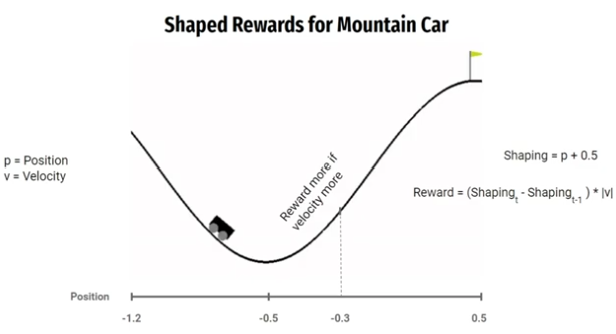

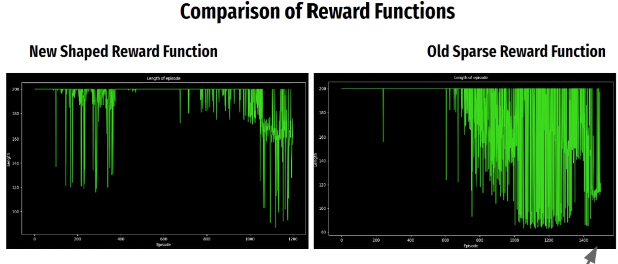

## 5.3 Faster Learning, but the Wrong Behavior

The first shaped reward improves the reported training speed:

- older reward: about **1500 episodes**,
- shaped reward: about **1200 episodes**.

But the learned behavior is wrong: the agent oscillates more than necessary and reaches the goal late.

Why? Because the shaping reward pays the agent for high-velocity oscillation. Extra oscillation can collect more reward before the final goal reward.

$$
\boxed{\text{The agent is correctly optimizing the reward it was given.}}
$$

The reward function is misaligned with the intended objective.

### Why the agent delays the goal

The agent is not violating the reward function. It is exploiting it correctly.

If repeated oscillations produce additional positive shaping rewards, then the agent can increase cumulative return by continuing those oscillations before finally taking the terminal reward. From the agent's perspective,

$$
\text{extra rewarded oscillations}+\text{goal reward}
$$

can be better than

$$
\text{quick goal reward}.
$$

The design therefore contains a loophole: it rewards a behavior that was intended only as a means to reach the goal, but the behavior itself becomes profitable.

This is an example of **reward hacking** or **specification gaming**: the agent finds a high-return strategy that satisfies the mathematical reward definition without satisfying the designer's real intention.


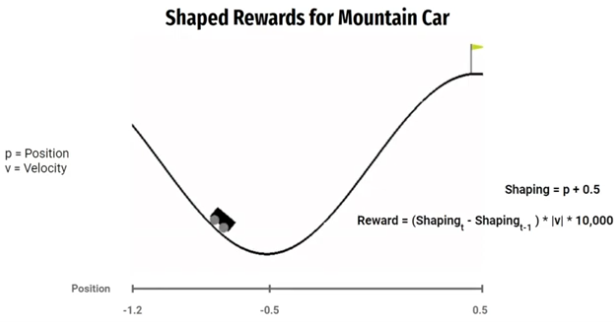

### Unintended Incentives / Reward Hacking

Never evaluate a reward function only by whether training reward increases.

Inspect:

- the learned trajectory,
- completion time,
- repeated loops or cycles,
- whether the agent delays termination,
- whether an auxiliary reward term dominates the true objective.

A useful diagnostic question is:

$$
\boxed{\text{What is the easiest way for the agent to earn return under my formula?}}
$$

This question should be asked before and after training.

If the answer is different from the real task objective, then the reward needs revision. Training curves alone may not reveal the problem because an exploited reward can produce excellent numerical return while the trajectory is undesirable.


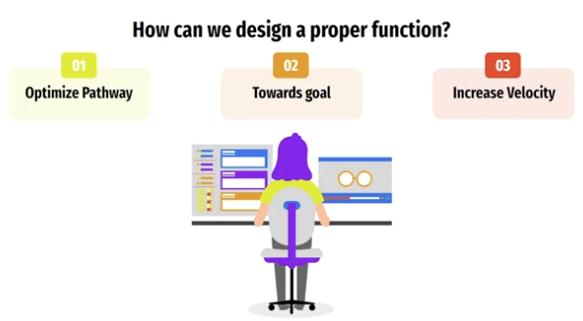

# 6. A Better Mountain Car Reward

The improved design tries to satisfy several objectives simultaneously:

1. give a large positive reward only when the goal is reached,
2. make every ordinary step negative,
3. make the penalty smaller when the car is closer to the goal,
4. make the penalty smaller when useful velocity is larger,
5. discourage unnecessary extra steps.

The redesign changes the logic of the Mountain Car reward. Instead of paying positive shaping rewards repeatedly in the valley, it reserves a large positive reward for actual success and keeps ordinary transitions negative.

This makes the objective closer to

$$
\boxed{\text{reach the goal, and do so efficiently}}.
$$

Position and velocity are still used, but now they adjust the **size of the penalty** rather than creating an unlimited source of positive reward before completion.


## 6.1 Terminal Reward

The goal receives

$$
\boxed{R_{\text{goal}}=+100}.
$$

The agent should not be able to collect positive reward indefinitely while still in the valley.

This terminal bonus gives successful completion a clear positive event. At the same time, the nonterminal design below avoids giving the agent a reason to remain in the valley merely to collect extra positive shaping rewards.


## 6.2 Negative Reward During the Valley

It illustrates the nonterminal reward as

$$
\boxed{R\propto\frac{p-0.5}{|v|}}
$$

with an additional constant divisor used to control numerical scale.

Because the rescaled position is negative:

- closer to the goal $\Rightarrow$ less negative reward,
- farther from the goal $\Rightarrow$ more negative reward.

For a fixed position:

- larger $|v|$ $\Rightarrow$ less negative reward,
- smaller $|v|$ $\Rightarrow$ more negative reward.

This encourages progress and momentum while keeping every nonterminal step costly.

### Reading the numerator

In the Mountain Car coordinate system used in the example, the goal is near $p=0.5$. Therefore,

$$
p-0.5<0
$$

for positions before the goal.

As the car approaches $0.5$, the numerator moves toward zero. The reward therefore becomes **less negative** near the goal.

For example,

$$
p=-0.5 \Rightarrow p-0.5=-1.0,
$$

while

$$
p=0.3 \Rightarrow p-0.5=-0.2.
$$

The second position is closer to the goal and receives a smaller penalty for the same velocity magnitude.

### Reading the denominator

For the same position, increasing $|v|$ makes the magnitude of the negative fraction smaller. This means that stronger motion is penalized less than weak motion at that position.

The design therefore uses two signals at once:

$$
\boxed{\text{closer position} \Rightarrow \text{smaller penalty}}
$$

and

$$
\boxed{\text{larger speed} \Rightarrow \text{smaller penalty}}.
$$

Because the reward remains negative during ordinary steps, taking unnecessary extra steps still reduces the total return.

### Exact scaled form shown in the source figure

The figure presents the nonterminal reward as

\[
\boxed{
R_t=\frac{p_t-0.5}{|v_t|\times 1000}
}
\]

while successful goal completion receives \(+100\).

The factor \(1000\) only rescales the numerical magnitude. The behavioral logic comes from the numerator and denominator:

\[
p_t\rightarrow 0.5
\Rightarrow p_t-0.5\rightarrow 0
\Rightarrow \text{reward becomes less negative},
\]

and, for a fixed position,

\[
|v_t|\uparrow
\Rightarrow
\left|
\frac{p_t-0.5}{|v_t|\times1000}
\right|\downarrow
\Rightarrow \text{reward becomes less negative}.
\]

Thus the car is still penalized at every ordinary step, but the penalty is reduced when it is closer to the goal or moving faster.


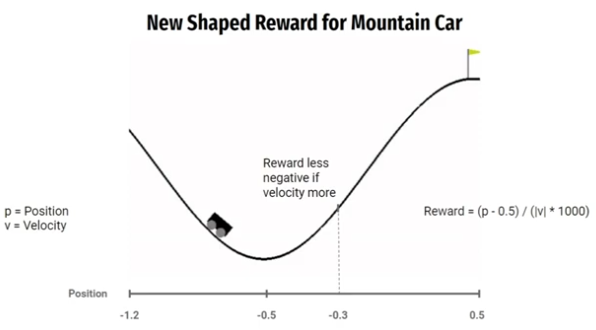

### Numerical implementation safeguard

The conceptual expression divides by $|v|$. In code, velocity can be zero, so use

$$
\boxed{R=\frac{p-0.5}{|v|+\varepsilon}}
$$

with $\varepsilon>0$ to prevent division by zero. A further scale factor can keep magnitudes numerically manageable.

The $\varepsilon$ term is a numerical safeguard, not a new behavioral objective. Without it, $v=0$ would make the denominator zero and the expression undefined.

For example, with

$$
\varepsilon=10^{-3},
$$

the denominator is at least $0.001$. This keeps the computation finite even when the car is momentarily stationary.

The additional scale factor serves a different purpose: it changes the magnitude of the reward values so that the numerical range is easier to work with while preserving the basic ordering of better and worse states.


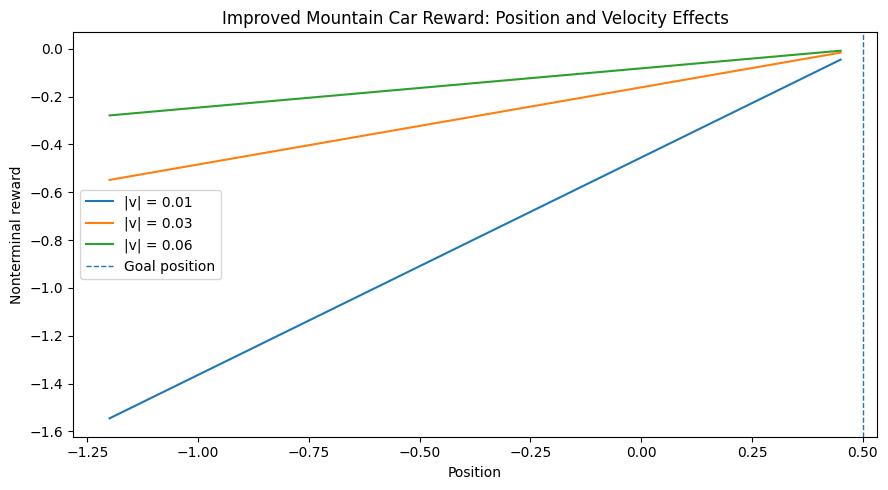

In [4]:
def improved_mountain_car_reward(position, velocity, goal_reached=False,
                                 terminal_reward=100.0, scale=100.0, epsilon=1e-3):
    if goal_reached:
        return terminal_reward
    return ((position - 0.5) / (abs(velocity) + epsilon)) / scale

positions = np.linspace(-1.2, 0.45, 300)
velocities = [0.01, 0.03, 0.06]

plt.figure(figsize=(9, 5))
for velocity in velocities:
    rewards = [improved_mountain_car_reward(p, velocity) for p in positions]
    plt.plot(positions, rewards, label=f"|v| = {velocity:.2f}")

plt.axvline(0.5, linestyle="--", linewidth=1, label="Goal position")
plt.xlabel("Position")
plt.ylabel("Nonterminal reward")
plt.title("Improved Mountain Car Reward: Position and Velocity Effects")
plt.legend()
plt.tight_layout()
plt.show()

It reports a large improvement:

- previous shaped reward: about **1200 episodes**,
- improved reward: about **350 episodes**.

The learned policy also reduces unnecessary oscillation and reaches the goal in fewer steps.

The improvement is important for two separate reasons. First, the reported training requires fewer episodes. Second, the observed policy better matches the actual objective: it avoids unnecessary oscillation and completes the task sooner.

That second point is the more important reward-design check. Faster convergence is useful only when the converged behavior is also the behavior we intended.


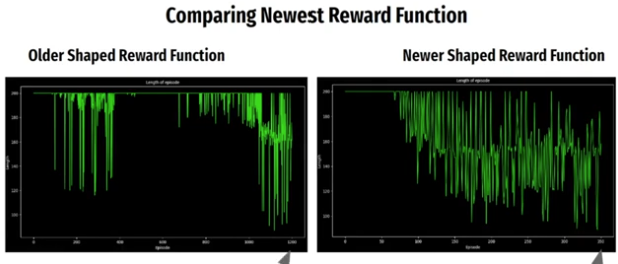

# 7. Reward-Design Principles

The examples suggest a practical set of principles.

## 7.1 Start from the True Objective

Write down what success actually means: reaching a goal, minimizing time, maintaining stability, avoiding unsafe states, reducing energy use, or satisfying constraints.

The highest-return behavior should match the real objective.

A practical way to define the true objective is to write a plain-language sentence before writing any equation. For example:

> Reach the terminal goal as quickly as possible without unsafe behavior.

Each reward term should then be traceable to part of that sentence. If a term cannot be connected to the actual objective, it deserves extra scrutiny.


## 7.2 Avoid Rewarding Unnecessary Delay

If the agent receives positive reward for every ordinary step, it may learn to prolong the episode.

When faster completion matters, a per-step cost such as

$$
R_{\text{step}}<0
$$

makes delay expensive.

The accumulated cost of delay can be seen directly. With $\gamma=1$ and a constant step cost $-c$,

$$
G_{\text{delay}}=-cN+R_{\text{terminal}},
$$

where $N$ is the number of nonterminal steps. Increasing $N$ decreases return, so unnecessary waiting becomes unattractive.


## 7.3 Give Useful Progress Information When Needed

Sparse rewards can be enough in small tasks, but they may provide very little guidance in large spaces.

Shaping variables can represent:

- distance to goal,
- orientation error,
- speed,
- stability,
- energy use,
- constraint violations.

A shaping variable should have a clear physical or task meaning. For example, distance can represent geometric progress, angle can represent stability, and energy use can represent control cost.

Adding more variables is not automatically better. Every additional term creates another incentive that the agent may optimize, so each term should be included for a specific reason.


## 7.4 Use Symmetric Error Measures for Symmetric Objectives

If deviation in either direction is undesirable, use direction-independent quantities such as

$$
|x|
$$

or

$$
x^2.
$$

This prevents the reward sign from changing merely because the system deviates left instead of right.

This principle applies far beyond CartPole. If a target value is $x^*=0$, then a symmetric error can be written as

$$
e=|x-x^*|
$$

or

$$
e=(x-x^*)^2.
$$

Both make equal-sized deviations on opposite sides comparable.


## 7.5 Reward Improvement

A common pattern  is

$$
\boxed{R_t=\Phi(S_t)-\Phi(S_{t-1})}.
$$

This rewards improvement from one state to the next rather than only the absolute state score.

Difference-based shaping answers the question **"Did the state improve?"**

- If $\Phi(S_t)>\Phi(S_{t-1})$, then $R_t>0$.
- If $\Phi(S_t)<\Phi(S_{t-1})$, then $R_t<0$.
- If the shaping quality is unchanged, then $R_t=0$.

This is why the previous shaping value must be stored from one transition to the next in an implementation of this idea.


## 7.6 Balance Reward Magnitudes

If one component is numerically much larger than the others, it can dominate learning.

Check that:

- auxiliary shaping terms guide rather than replace the objective,
- terminal success remains meaningful,
- penalties are strong enough to matter,
- no accidental term overwhelms the desired behavior.

For a multi-term reward such as

$$
R=w_1r_1+w_2r_2+\cdots+w_kr_k,
$$

the weights $w_i$ control the relative influence of the components.

A component with a much larger numerical range can dominate even if it was intended only as a small hint. Reward-scale inspection should therefore include both the coefficients and the typical values that each term can actually produce during an episode.


## 7.7 Inspect Behavior, Not Only Curves

The first Mountain Car shaping function improved training speed but produced the wrong trajectory.

Always inspect both

$$
\boxed{\text{learning metrics}}
$$

and

$$
\boxed{\text{actual agent behavior}}.
$$

A useful evaluation set includes at least the episode return, episode length, success or completion rate when available, and direct inspection of trajectories or animations.

The Mountain Car example demonstrates why: a reward curve can improve while the policy learns to exploit an unintended incentive.


# 8. Lunar Lander

It then applies these ideas to Lunar Lander. The task is to land on the landing pad within a limited number of steps while controlling position, velocity, orientation, and engine use.

The landing pad is centered around $(0,0)$ in the coordinate description used by the source. Horizontal position is represented by $x$ and vertical position by $y$. The lander can use a main engine for vertical control and side/orientation engines for attitude control.

This task is harder to reward than GridWorld because a good landing is not defined only by final position. The lander should also approach with controlled velocity and orientation, make ground contact appropriately, and avoid wasting excessive engine effort.

### Episode limit and coordinate convention used in the source

The source describes the task as landing the vehicle within **1000 steps**.

The landing pad is at approximately

\[
(x,y)=(0,0).
\]

Its coordinate convention is:

- \(x>0\): lander is to the right of the landing pad,
- \(x<0\): lander is to the left,
- \(y>0\): lander is above the pad,
- \(y<0\): lander is below the pad.

The main engine is mounted at the bottom of the lander, while the left and right engines are used to control orientation.


## 8.1 Action Space

There are four discrete actions:

1. do nothing,
2. fire the left orientation engine,
3. fire the main engine,
4. fire the right orientation engine.

These actions create a discrete control problem even though the state variables themselves are continuous. The DQN therefore receives an eight-dimensional state and estimates one action value for each of the four possible discrete actions.


## 8.2 State Vector

The state has eight elements:

$$
\boxed{[x,\ y,\ v_x,\ v_y,\ \theta,\ \omega,\ LLC,\ RLC]}
$$

where

- $x,y$: position,
- $v_x,v_y$: linear velocity,
- $\theta$: angle,
- $\omega$: angular velocity,
- $LLC$: left-leg contact,
- $RLC$: right-leg contact.

The contact indicators are binary.

### Meaning of the eight state components

The vector combines motion, orientation, and contact information:

$$
s_t=
[x_t,\ y_t,\ v_{x,t},\ v_{y,t},\ \theta_t,\ \omega_t,\ LLC_t,\ RLC_t].
$$

The first six entries are continuous quantities describing where the lander is and how it is moving. The final two entries are contact indicators:

$$
LLC_t\in\{0,1\},\qquad RLC_t\in\{0,1\}.
$$

A value of $1$ means the corresponding leg is touching the ground, while $0$ means it is not.


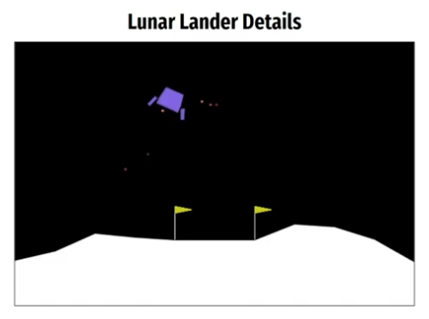

## 8.3 Shaping Function

It shows

$$
\boxed{
\Phi=
-100\sqrt{x^2+y^2}
-100\sqrt{v_x^2+v_y^2}
-100|\theta|
+10LLC
+10RLC
}
$$

Interpretation:

- distance from the landing region is penalized,
- large linear velocity is penalized,
- angular deviation is penalized,
- leg contact improves the shaping score.

The transition shaping reward is

$$
\boxed{R_{\text{shape}}=\Phi_t-\Phi_{t-1}}.
$$

### Interpreting the shaping score term by term

The position term

$$
-100\sqrt{x^2+y^2}
$$

becomes more negative as the lander moves farther from the landing region.

The velocity term

$$
-100\sqrt{v_x^2+v_y^2}
$$

penalizes large translational speed. A lander near the pad but moving very fast is therefore not considered as desirable as one approaching more gently.

The orientation term

$$
-100|\theta|
$$

penalizes tilt in either direction. The absolute value is appropriate because left and right angular deviations are both undesirable.

The contact terms

$$
+10LLC+10RLC
$$

increase the shaping score when the legs establish ground contact.

Because the actual transition reward uses

$$
R_{\text{shape}}=\Phi_t-\Phi_{t-1},
$$

the agent receives positive shaping when the new state is more stable according to these measures and negative shaping when the state deteriorates.


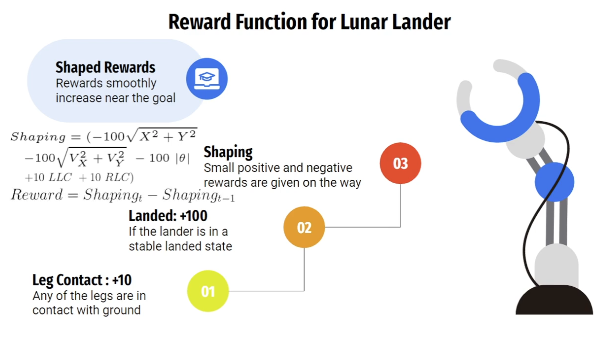

## 8.4 Terminal, Contact, and Engine Terms

The video highlights:

- leg contact: $+10$ through the contact terms,
- successful stable landing: $+100$,
- main engine use: $-0.3$,
- orientation-engine use: $-0.03$.

The reward therefore combines stability, task completion, and control effort.

### Why engine use is penalized

Engine firings are useful, but they should not be free. Without an engine-use cost, the agent could have less incentive to learn economical control.

The penalties make control effort part of the objective:

$$
R_{\text{main}}=-0.3
$$

for the main engine and

$$
R_{\text{side}}=-0.03
$$

for an orientation engine in the source example.

The main engine has the larger penalty, so the agent must trade the benefit of correcting its trajectory against the cost of firing an engine. The complete reward is therefore balancing several goals at once: move toward a stable landing state, establish successful contact, complete the landing, and avoid unnecessary control effort.


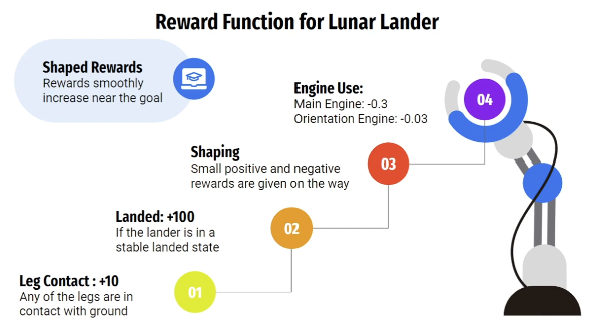

In [5]:
def lunar_shaping(state):
    x, y, vx, vy, theta, omega, left_contact, right_contact = state
    return (
        -100.0 * np.sqrt(x**2 + y**2)
        -100.0 * np.sqrt(vx**2 + vy**2)
        -100.0 * abs(theta)
        +10.0 * left_contact
        +10.0 * right_contact
    )

def lunar_transition_reward(previous_state, current_state, action, landed=False):
    reward = lunar_shaping(current_state) - lunar_shaping(previous_state)
    if landed:
        reward += 100.0
    if action == 2:
        reward -= 0.3
    elif action in (1, 3):
        reward -= 0.03
    return reward

previous = np.array([0.20, 0.40, 0.08, -0.10, 0.15, 0.02, 0, 0])
improved = np.array([0.12, 0.25, 0.04, -0.06, 0.08, 0.01, 0, 0])
worse = np.array([0.30, 0.55, 0.12, -0.16, 0.25, 0.04, 0, 0])

print("Reward when moving toward a stable state:", round(lunar_transition_reward(previous, improved, 0), 3))
print("Reward when moving away from a stable state:", round(lunar_transition_reward(previous, worse, 0), 3))

Reward when moving toward a stable state: 29.586
Reward when moving away from a stable state: -35.122


# 9. Lunar Lander Training Setup
The training portion reuses the DQN implementation from the earlier lesson and adapts it to Lunar Lander.


- environment: `LunarLander-v2`,
- state input: 8 values,
- hidden layers: three layers of 64 units,
- output: 4 action values,
- optimizer: Adam,
- loss: Huber loss,
- target network: used,
- training episodes: 600 in the demonstrated run, with 800 mentioned as another option.

The reward is taken directly from the environment rather than manually recomputing it inside the DQN loop.

### Why the network dimensions change

The DQN maps the current state to one estimated action value per action:

$$
[x,y,v_x,v_y,\theta,\omega,LLC,RLC]
\longrightarrow
[Q(s,a_0),Q(s,a_1),Q(s,a_2),Q(s,a_3)].
$$

So the input layer must accept 8 state values and the output layer must produce 4 Q-values. The greedy action is then selected from the largest predicted Q-value, while the exploration policy can still choose random actions during training.

The DQN machinery itself does not need a new reward formula inside the training loop because the environment already returns the reward after each action.

### Training, plotting, and evaluation scripts in the source workflow

The source keeps three roles separate:

1. the **training script** runs DQN learning,
2. the **plotter script** reads the saved metrics and displays training graphs in real time,
3. the **evaluator script** loads the trained Q-network and displays the learned behavior.

The Lunar Lander trainer is adapted from the earlier DQN example rather than rebuilding DQN from the beginning. The environment-specific changes are mainly the 8-dimensional input, 4-action output, Lunar Lander environment, episode count, and direct use of the environment reward.


## 9.1 Implementation Notes

- rewards were converted from `float64` to `float32` in that implementation,
- random exploration must select among four actions,
- Box2D is required for the Lunar Lander environment,
- the author encountered a Box2D installation problem and used an alternative compatible package.

These are environment/setup details rather than changes to the RL algorithm itself.

The `float32` conversion is a data-type compatibility detail. It does not change what the reward means; it only makes the reward representation consistent with the numerical type expected by the implementation.

Similarly, Box2D is part of the environment's simulation dependency. Installing it changes whether Lunar Lander can run, not the definition of DQN.

This distinction is useful: **environment setup**, **reward design**, and **learning algorithm** are separate layers of the implementation.



# 10. Lunar Lander Training Results

It shows a useful learning pattern.

### Early training
The policy is mostly random, so the lander often crashes quickly and episodes are short.

### Middle stage
The agent learns to keep the lander stable in the air. It can hover for nearly the full episode limit, so episode length becomes very large.

### Later stage
The agent learns to descend and land, so episode length falls again while total episode reward rises.

### Why episode length first rises and then falls

Episode length alone can be misleading.

At the beginning,

$$
\text{short episode} \not\Rightarrow \text{good policy},
$$

because the episode may be short simply because the lander crashes quickly.

During the middle stage, longer episodes can indicate an improvement: the agent has learned enough control to avoid immediate failure and can hover for much longer.

Later, once stable control has been learned, the agent can improve further by descending and finishing the task successfully. Episode length then drops because the lander no longer spends the full horizon hovering.

So the interpretation depends on behavior:

$$
\boxed{\text{short crash} \rightarrow \text{long stable hover} \rightarrow \text{shorter controlled landing}}.
$$

### What the four displayed training plots represent

The source screenshot shows four training plots:

- **Total Reward per episode**
- **Length of episode**
- **Average Q**
- **Exploration**, shown through the decreasing $\epsilon$ value

The narration focuses mainly on the first two. Total reward rises as the policy improves. Episode length follows the more unusual low $\rightarrow$ high $\rightarrow$ lower pattern because the agent first crashes quickly, then learns to hover for nearly the full 1000-step horizon, and finally learns to land instead of hovering indefinitely.

The Average-Q plot gives another view of the network's learned action-value estimates, while the Exploration plot shows the gradual reduction in random action selection as \(\epsilon\) decreases.


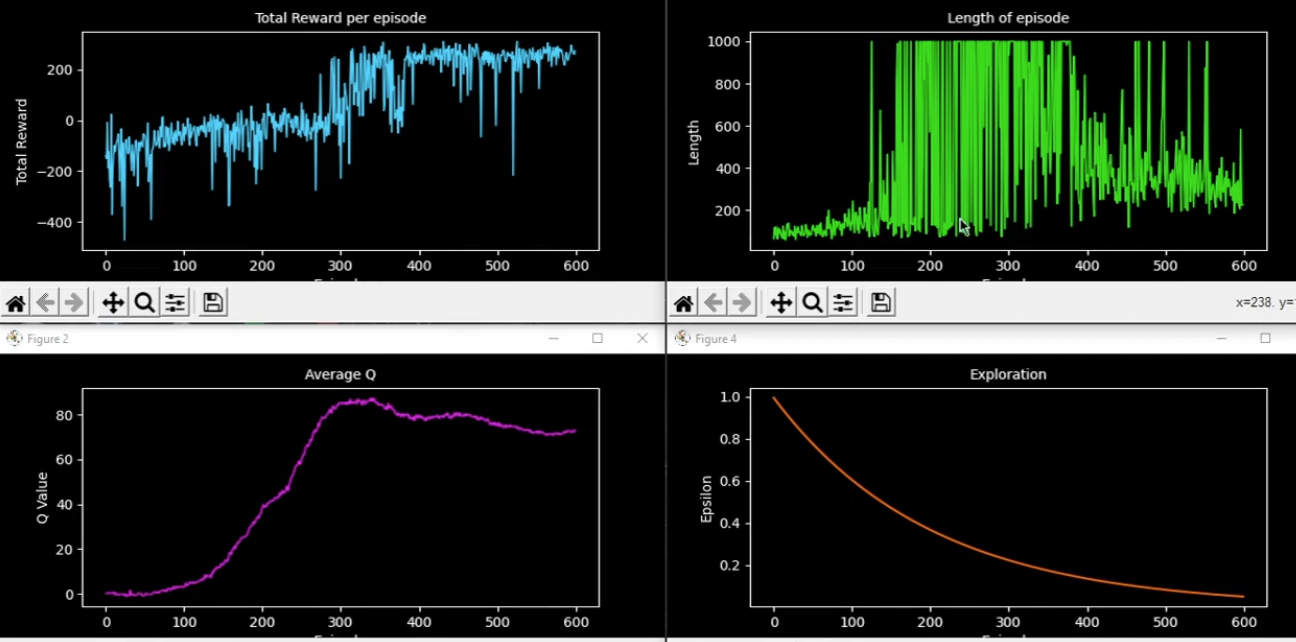

A temporary increase in episode length is not necessarily failure. Here it reflects an intermediate skill: **hovering successfully** before learning controlled landing.

This is a good example of why a single metric should not be interpreted in isolation. A temporary increase in episode length can represent genuine skill acquisition when survival or stability is an intermediate step toward the final objective.

## 10.1 Evaluating the Trained Lunar Lander

After training, the source switches the evaluator from the earlier environment to `LunarLander-v2`, loads the trained Q-network, and uses the four-action Lunar Lander action space.

The purpose of the evaluator is different from the training plots. Training metrics tell us whether numerical quantities changed during learning; evaluation lets us directly inspect the resulting policy.

In the demonstrated evaluation, the trained agent performs a smooth landing. This final behavioral check is important because the earlier Mountain Car example already showed that a good-looking reward curve does not guarantee desirable behavior.


# 11. Practical Reward-Design Workflow

### Step 1 — Define success precisely
Write the real objective in measurable terms.

### Step 2 — Identify failure modes
List behavior that must be avoided.

### Step 3 — Start with the simplest reward
Use terminal rewards and basic penalties first.

### Step 4 — Check whether the reward is too sparse
If the agent receives almost no useful signal, add carefully chosen shaping.

### Step 5 — Choose shaping variables
Use quantities that genuinely measure progress, stability, safety, efficiency, or constraint satisfaction.

### Step 6 — Check reward signs
Improvement should produce better reward; deterioration should produce worse reward.

### Step 7 — Check symmetry
Use $|x|$ or $x^2$ when positive and negative deviations should be treated equally.

### Step 8 — Check scale
Make sure auxiliary terms do not overwhelm the true objective.

### Step 9 — Search for loopholes
Ask: **Can the agent collect reward without completing the task?**

### Step 10 — Inspect trajectories after training
Do not trust total reward alone. Watch what the learned policy actually does.

### Step 11 — Revise and retrain
Reward design is usually iterative.

### A useful check after every revision

After changing a reward, compare at least two candidate trajectories by hand and compute which one receives the higher return. Ask whether the preferred trajectory is also the one you would choose based on the real task objective.

This small manual check can expose many reward errors before a long training run.


# 12. Common Reward-Design Failure Modes

| Failure mode | Symptom | Example from the video | Typical correction |
|---|---|---|---|
| Reward too sparse | Very slow learning | GridWorld with only terminal reward | Add informative shaping |
| Reward for every step | Agent delays termination | Positive step rewards | Use step cost when speed matters |
| Sign-sensitive shaping | Left/right deviations treated differently | Raw CartPole angle | Use absolute value or square |
| Auxiliary reward dominates | Agent exploits side objective | Mountain Car velocity shaping | Redesign so terminal objective remains dominant |
| No cost for delay | Unnecessary long trajectories | First Mountain Car shaping | Make ordinary steps negative |
| Reward scale poorly balanced | One term controls behavior | Multi-term shaped rewards | Rescale terms |
| Metrics interpreted alone | Wrong conclusion about learning | Lunar Lander episode length | Inspect reward, episode length, and behavior together |

The common pattern across these failures is **objective mismatch**. The agent follows the numerical incentives exactly, while the designer may be thinking about an unstated objective that never entered the reward.

For each failure mode, the correction should therefore change the incentives rather than simply increasing training time or changing the optimizer.


# 13. Key Reward-Shaping Equations

### Difference-based shaping

$$
\boxed{R_t=\Phi(S_t)-\Phi(S_{t-1})}
$$

### CartPole

$$
\boxed{\Phi_t=-\left(pa_t^2+cp_t^2+cv_t^2+pav_t^2\right)}
$$

### First Mountain Car shaping idea

$$
\boxed{\Phi_t=p_t+0.5}
$$

### Improved Mountain Car reward

$$
\boxed{R\propto\frac{p-0.5}{|v|}}
$$

with numerical scaling and a safe denominator in code.

### Lunar Lander

$$
\boxed{\Phi=-100\sqrt{x^2+y^2}-100\sqrt{v_x^2+v_y^2}-100|\theta|+10LLC+10RLC}
$$

$$
\boxed{R_{\text{shape}}=\Phi_t-\Phi_{t-1}}
$$

### How the equations connect

The examples follow the same basic pattern:

1. define a state-quality measure or task reward;
2. make desirable transitions produce a better numerical signal;
3. verify that cumulative return favors the intended full trajectory.

For the difference-based examples,

$$
\Phi_t>\Phi_{t-1}
\Rightarrow
R_t>0,
$$

while

$$
\Phi_t<\Phi_{t-1}
\Rightarrow
R_t<0.
$$

For the improved Mountain Car design, the reward remains negative before the goal, so improvement is represented by a **less negative** penalty rather than repeated positive reward.


# 14. Further Directions

The final part of the video points toward:

- **Sutton and Barto, Reinforcement Learning: An Introduction**,
- continuous action spaces and policy-gradient methods,
- actor–critic methods,
- reusable RL software architectures,
- self-play,
- hierarchical reinforcement learning.

These directions also show how reward design remains relevant as the algorithm changes. Policy-gradient and actor-critic methods optimize policies differently from DQN, but they still depend on the reward signal that defines which trajectories are preferred.

Reusable software architecture is useful for the same reason: the environment interface, reward handling, learning algorithm, evaluation, and visualization can be separated so that a new environment does not require rewriting the entire training system.

### What each suggested next direction means

- **Policy-gradient methods:** useful when directly learning a policy, especially for action spaces that are not naturally handled by a finite set of Q-values.
- **Actor–critic methods:** learn both a policy component (actor) and a value-estimation component (critic).
- **Reusable architectures:** separate environment handling, learning logic, metrics, saving, and evaluation so a new problem does not require copying the whole implementation.
- **Self-play:** agents can improve by repeatedly playing against other agents or versions of themselves.
- **Hierarchical reinforcement learning:** divide a large RL problem into smaller subproblems or skills and solve them at different levels.

These points are the source's closing directions after the reward-design and Lunar Lander examples.


# 15. Final Takeaways

1. Reward design can be as important as the learning algorithm.
2. Sparse rewards may make exploration extremely slow.
3. Dense rewards can still be wrong if they encourage undesirable behavior.
4. A negative step cost is useful when fast completion matters.
5. Shaped rewards can provide informative feedback before terminal success.
6. Squared or absolute error terms are useful when deviations in either direction are undesirable.
7. Difference-based shaping can reward improvement from one state to the next.
8. Reward components must be scaled so auxiliary terms do not dominate the true objective.
9. Mountain Car demonstrates how a reasonable-looking reward can create unintended behavior.
10. Always inspect the learned behavior, not only the reward curve.
11. Lunar Lander combines position, velocity, orientation, contact, terminal success, and engine-use terms.
12. A good reward should make the highest-return policy correspond as closely as possible to the behavior actually desired.

A compact mental model for the entire notebook is

$$
\boxed{
\text{objective}
\rightarrow
\text{reward}
\rightarrow
\text{return}
\rightarrow
\text{policy}
\rightarrow
\text{observed behavior}
}
$$

If the observed behavior is wrong, inspect the reward before assuming that the learning algorithm itself is the problem. The Mountain Car example is the clearest demonstration: an agent can optimize the specified reward successfully and still behave differently from what the designer intended.


## Source Note

https://www.youtube.com/watch?v=IdJL9rcQrFU&list=PLKnIA16_RmvbMK0_fdp0DZHZKm4Q1slAB&index=6